In [3]:
import os
# Check current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in directory:", os.listdir())

Current working directory: c:\Users\User\.ipython\.venv\geopandas-coures-files\geopandas-coures-files\Spatial_Data_Analysis
Files in directory: ['Analyis2.ipynb', 'Analysis1.ipynb', 'Analysis3.ipynb', 'Analysis4.ipynb', 'brexit_vote.csv', 'chart.png', 'choropleth_map.png', 'correlation.png', 'DSd.cpg', 'DSd.dbf', 'DSd.prj', 'DSd.sbn', 'DSd.sbx', 'DSd.shp', 'DSd.shp.xml', 'DSd.shx', 'Kandy_data.cpg', 'Kandy_data.dbf', 'Kandy_data.prj', 'Kandy_data.sbn', 'Kandy_data.sbx', 'Kandy_data.shp', 'Kandy_data.shp.xml', 'Kandy_data.shx', 'local_authority_districts.geojson', 'mis.ipynb', 'Nuwara_Data.cpg', 'Nuwara_Data.dbf', 'Nuwara_Data.prj', 'Nuwara_Data.sbn', 'Nuwara_Data.sbx', 'Nuwara_Data.shp', 'Nuwara_Data.shp.xml', 'Nuwara_Data.shx', 'output.pdf', 'Population_data.cpg', 'Population_data.dbf', 'Population_data.prj', 'Population_data.sbn', 'Population_data.sbx', 'Population_data.shp', 'Population_data.shp.xml', 'Population_data.shx', 'RVR_Kreise.cpg', 'RVR_Kreise.dbf', 'RVR_Kreise.prj', 'RVR_

In [4]:
import matplotlib.pyplot as plt  # Graphics
from matplotlib import colors
import seaborn  # Graphics
import geopandas  # Spatial data manipulation
import pandas  # Tabular data manipulation
import rioxarray  # Surface data manipulation
import xarray  # Surface data manipulation
from pysal.explore import esda  # Exploratory Spatial analytics
from pysal.lib import weights  # Spatial weights
import contextily  # Background tiles
import seaborn

c:\Users\User\.ipython\.venv\Lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [5]:
ref = pandas.read_csv(
    "brexit_vote.csv", index_col="Area_Code"
)
ref.head()

,id,Region_Code,Region,Area,Electorate,ExpectedBallots,VerifiedBallotPapers,Pct_Turnout,Votes_Cast,Valid_Votes,Remain,Leave,Rejected_Ballots,No_official_mark,Voting_for_both_answers,Writing_or_mark,Unmarked_or_void,Pct_Remain,Pct_Leave,Pct_Rejected
Area_Code,,,,,,,,,,,,,,,,,,,,
E06000031,108,E12000006,East,Peterborough,120892,87474,87469,72.35,87469,87392,34176,53216,77,0,32,7,38,39.11,60.89,0.09
E06000032,109,E12000006,East,Luton,127612,84633,84636,66.31,84616,84481,36708,47773,135,0,85,0,50,43.45,56.55,0.16
E06000033,112,E12000006,East,Southend-on-Sea,128856,93948,93939,72.90,93939,93870,39348,54522,69,0,21,0,48,41.92,58.08,0.07
E06000034,113,E12000006,East,Thurrock,109897,79969,79954,72.75,79950,79916,22151,57765,34,0,8,3,23,27.72,72.28,0.04
E06000055,110,E12000006,East,Bedford,119530,86136,86136,72.06,86135,86066,41497,44569,69,0,26,1,42,48.22,51.78,0.08


In [6]:
lads = geopandas.read_file(
    "local_authority_districts.geojson"
).set_index("lad16cd")

In [7]:
db = (
    geopandas.GeoDataFrame(
        lads.join(ref[["Pct_Leave"]]), crs=lads.crs
    )
    .to_crs(epsg=3857)[
        ["objectid", "lad16nm", "Pct_Leave", "geometry"]
    ]
    .dropna()
)

db.info()
db.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000023
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   objectid   380 non-null    int32   
 1   lad16nm    380 non-null    object  
 2   Pct_Leave  380 non-null    float64 
 3   geometry   380 non-null    geometry
dtypes: float64(1), geometry(1), int32(1), object(1)
memory usage: 13.4+ KB


,objectid,lad16nm,Pct_Leave,geometry
lad16cd,,,,
E06000001,1,Hartlepool,69.57,"MULTIPOLYGON (((-141402.215 7309092.065, -1537..."
E06000002,2,Middlesbrough,65.48,"MULTIPOLYGON (((-136924.099 7281563.141, -1426..."
E06000003,3,Redcar and Cleveland,66.19,"MULTIPOLYGON (((-126588.382 7293641.928, -1260..."
E06000004,4,Stockton-on-Tees,61.73,"MULTIPOLYGON (((-146690.634 7293316.144, -1537..."
E06000010,10,"Kingston upon Hull, City of",67.62,"MULTIPOLYGON (((-35191.009 7134866.244, -39368..."


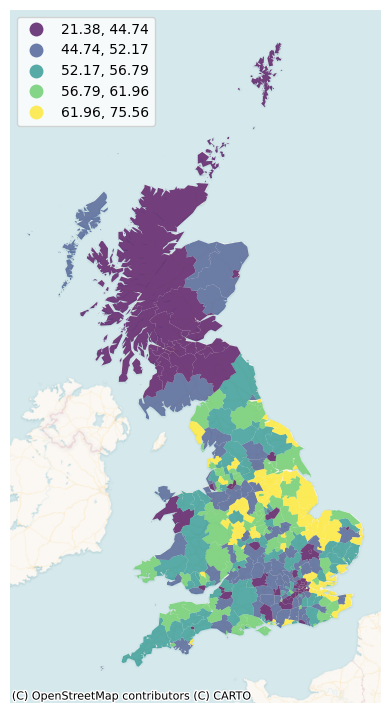

In [8]:
# Set up figure and a single axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Build choropleth
db.plot(
    column="Pct_Leave",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds=dict(loc=2),
    ax=ax,
)
# Add basemap
contextily.add_basemap(
    ax,
    crs=db.crs,
    source=contextily.providers.CartoDB.VoyagerNoLabels,
)
# Remove axes
ax.set_axis_off();

In [9]:
# Save the figure
f.savefig("choropleth_map.png",  # file name
          dpi=300,               # resolution
          bbox_inches='tight',   # remove extra whitespace
          transparent=False)     # make background opaque


In [10]:
# Generate W from the GeoDataFrame
w = weights.distance.KNN.from_dataframe(db, k=8)
# Row-standardization
w.transform = "R"

#Motivating local spatial autocorrelation

In [11]:
db["w_Pct_Leave"] = weights.lag_spatial(w, db['Pct_Leave'])

In [12]:
db["Pct_Leave_std"] = db["Pct_Leave"] - db["Pct_Leave"].mean()
db["w_Pct_Leave_std"] = weights.lag_spatial(w, db['Pct_Leave_std'])

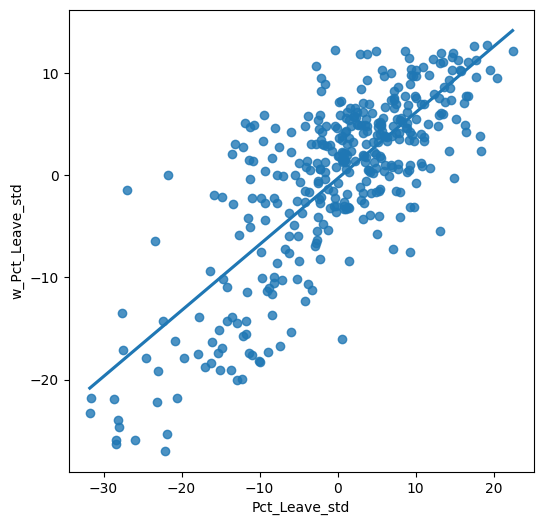

In [13]:
# Set up the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
seaborn.regplot(
    x="Pct_Leave_std", y="w_Pct_Leave_std", data=db, ci=None
)
plt.show()

In [14]:
f.savefig("correlation.png",  # file name
          dpi=300,               # resolution
          bbox_inches='tight',   # remove extra whitespace
          transparent=False)     # make background opaque


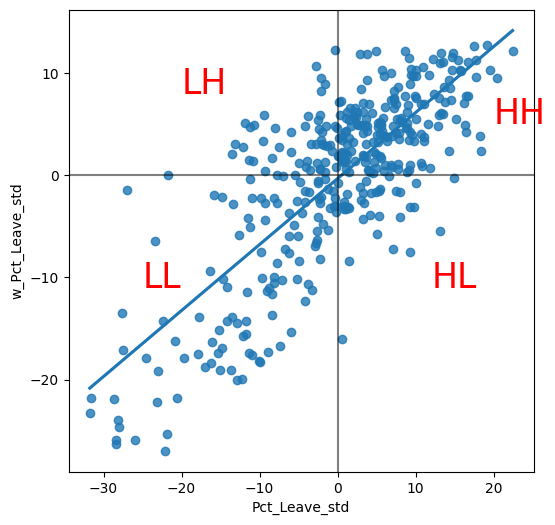

In [15]:
# Set up the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
seaborn.regplot(
    x="Pct_Leave_std", y="w_Pct_Leave_std", data=db, ci=None
)
# Add vertical and horizontal lines
plt.axvline(0, c="k", alpha=0.5)
plt.axhline(0, c="k", alpha=0.5)
# Add text labels for each quadrant
plt.text(20, 5, "HH", fontsize=25, c="r")
plt.text(12, -11, "HL", fontsize=25, c="r")
plt.text(-20, 8.0, "LH", fontsize=25, c="r")
plt.text(-25, -11.0, "LL", fontsize=25, c="r")
# Display
plt.show()

In [20]:
lisa = esda.moran.Moran_Local(db["Pct_Leave"], w)

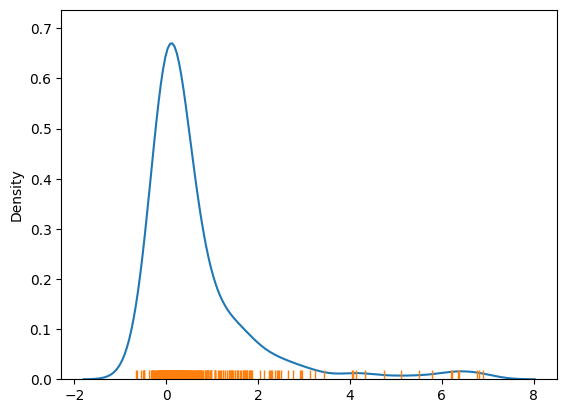

In [24]:
# Draw KDE line
ax = seaborn.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
seaborn.rugplot(lisa.Is, ax=ax);
plt.savefig("kde_rugplot.png", dpi=300, bbox_inches='tight')  # dpi=300 for high quality

In [26]:
from splot import esda as esdaplot

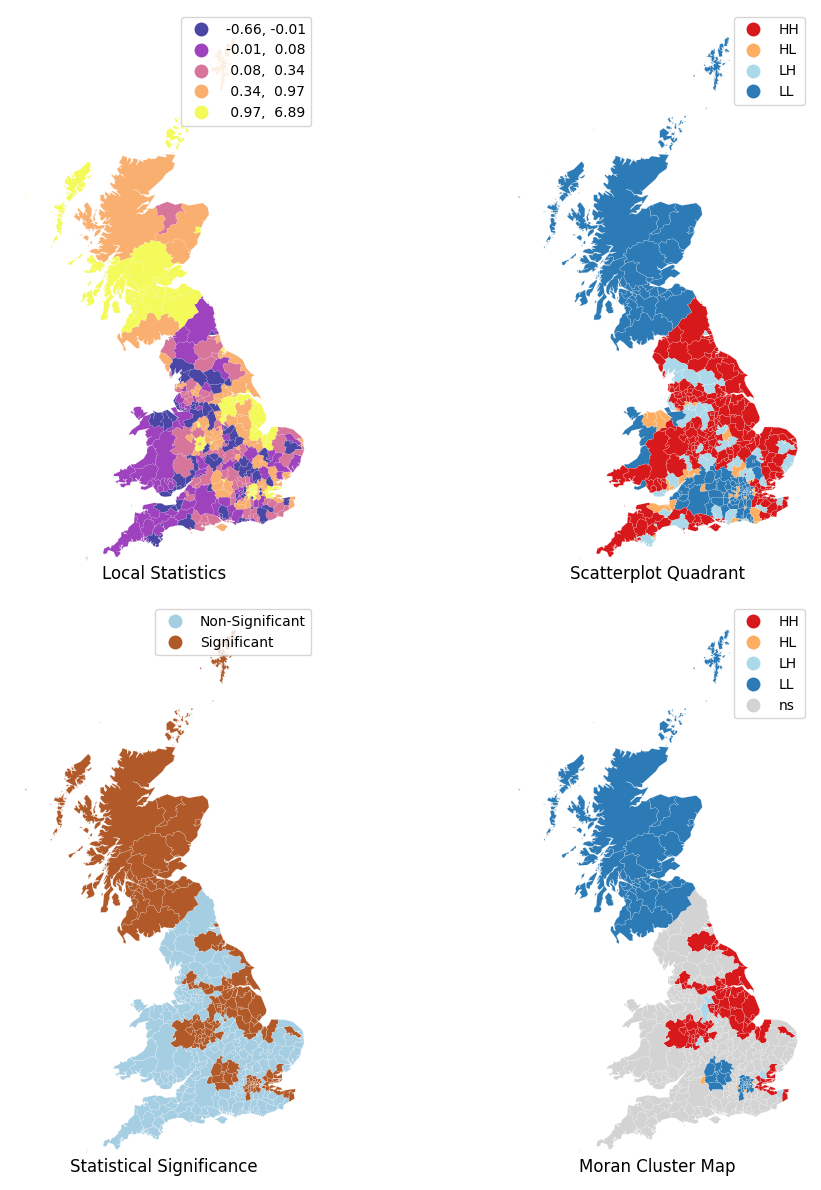

<Figure size 640x480 with 0 Axes>

In [28]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
db.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quadrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, db, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pandas.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=db.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
db.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quadrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, db, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimize in-between white space
f.tight_layout()

# Display the figure
plt.show()

plt.savefig("Distribution_Pattern.png", dpi=300, bbox_inches='tight')  # dpi=300 for high quality

In [29]:
# Save the figure
f.savefig("distribution_map.png",  # file name
          dpi=300,               # resolution
          bbox_inches='tight',   # remove extra whitespace
          transparent=False)     # make background opaque

In [40]:
lisa.q[:10]

array([1, 1, 1, 1, 1, 1, 4, 1, 4, 1])

In [41]:
counts = pandas.value_counts(lisa.q)
counts

C:\Users\User\AppData\Local\Temp\ipykernel_11940\3518240389.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  counts = pandas.value_counts(lisa.q)


1    183
3    113
2     50
4     34
Name: count, dtype: int64

In [42]:
(lisa.p_sim < 0.05).sum() * 100 / len(lisa.p_sim)

41.05263157894737

In [43]:
# Assign pseudo P-values to `db`
db["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
db["sig"] = sig
# Print top of the table to inspect
db[["sig", "p-sim"]].head()

,sig,p-sim
lad16cd,,
E06000001,1,0.006
E06000002,1,0.005
E06000003,1,0.007
E06000004,1,0.007
E06000010,1,0.009


In [44]:
# Print bottom of the table to inspect
db[["sig", "p-sim"]].tail()

,sig,p-sim
lad16cd,,
W06000018,0,0.454
W06000019,0,0.436
W06000021,0,0.418
W06000022,0,0.389
W06000023,0,0.243


In [45]:
# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
db["labels"] = pandas.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=db.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
db["labels"].head()

lad16cd
E06000001    HH
E06000002    HH
E06000003    HH
E06000004    HH
E06000010    HH
Name: labels, dtype: object

In [46]:
db["labels"].value_counts()

labels
Non-Significant    224
HH                  77
LL                  67
LH                   8
HL                   4
Name: count, dtype: int64

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


''

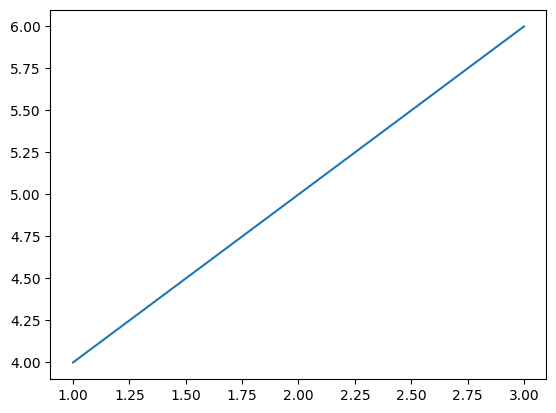

In [2]:
%pip install fpdf

import matplotlib.pyplot as plt
from fpdf import FPDF

# Example chart
plt.plot([1,2,3], [4,5,6])
plt.savefig("chart.png")

# Create PDF
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

# Add code text (replace with actual code or a placeholder)
code_text = "# Example code goes here\nplt.plot([1,2,3], [4,5,6])"
pdf.multi_cell(0, 5, code_text)

# Add chart image
pdf.image("chart.png", x=10, y=pdf.get_y(), w=100)

pdf.output("output.pdf")
